# Módulo 30 - K-Means
**Atividade:**

Nesta tarefa, vamos explorar o algoritmo de clustering K-means aplicado a um contexto diferente do usual. Em vez de segmentar perfis de viajantes ou clientes de e-commerce, vamos usar dados biológicos para segmentar diferentes espécies de pinguins com base em características físicas. Esta abordagem destaca a versatilidade do K-means para diversas áreas além de vendas e marketing.

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.

species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
penguins = sns.load_dataset('penguins')

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.

In [4]:
# seu código aqui
penguins.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [5]:
(penguins.isnull().sum() / len(penguins)) * 100

species              0.000000
island               0.000000
bill_length_mm       0.581395
bill_depth_mm        0.581395
flipper_length_mm    0.581395
body_mass_g          0.581395
sex                  3.197674
dtype: float64

In [6]:
penguins.dropna(subset=['bill_length_mm'], inplace=True)

In [7]:
penguins.dropna(subset=['bill_length_mm'], inplace=True)
penguins.dropna(subset=['bill_depth_mm'], inplace=True)
penguins.dropna(subset=['flipper_length_mm'], inplace=True)
penguins.dropna(subset=['body_mass_g'], inplace=True)

In [8]:
# Só fiz a exclusão devido a solicitação do exercício, mas por mim transformava a variavel sex em 0 e 1 e 
# verificava o resultado da classificação do modelo
penguins_sem_sex = penguins.drop('sex', axis=1)
penguins_sem_sex.drop('species', axis=1, inplace=True)
penguins_sem_sex.drop('island', axis=1, inplace=True)
penguins_sem_sex

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? Se sim, quantos?

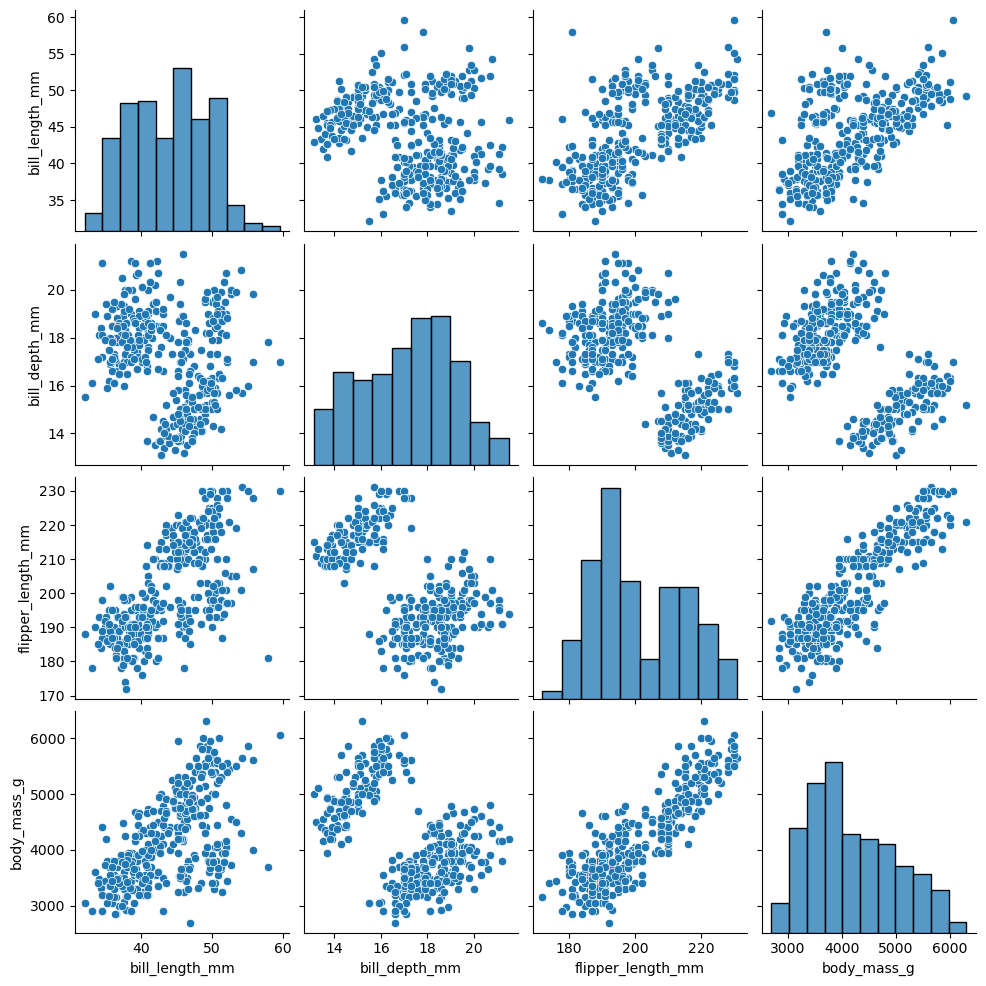

In [9]:
# seu código aqui
sns.pairplot(penguins_sem_sex)

#### A variavel referente a profundidade do bico(bill_depth_mm) com o comprimento da barbatana(flipper_length_mm) nos ajudam a ver dois grupos separados de forma clara. A massa corporal(body_mass_g) com a profundidade do bico também nos ajuda a ver claramente dois grupos distintos. As outras variáveis conseguimos ver três grupos se formando, embora não tão separados e distintos quanto as variáveis sitadas anteriormente.

# 3 - Realize a padronização dos dados e visualize os dados.

In [10]:
# seu código aqui
base_padronizado = penguins_sem_sex.copy()

In [11]:
colunas_padronizar = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
# Inicializar o StandardScaler
scaler = StandardScaler()
# Ajustar e transformar os dados selecionados
base_padronizado[colunas_padronizar] = scaler.fit_transform(penguins_sem_sex[colunas_padronizar])

In [12]:
base_padronizado

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.884499,0.785449,-1.418347,-0.564142
1,-0.811126,0.126188,-1.062250,-0.501703
2,-0.664380,0.430462,-0.421277,-1.188532
4,-1.324737,1.089724,-0.563715,-0.938776
5,-0.847812,1.748985,-0.777373,-0.689020
...,...,...,...,...
338,0.601305,-1.750171,0.931890,0.903175
340,0.527932,-1.445897,1.003109,0.809516
341,1.188289,-0.735923,1.501644,1.933419
342,0.234440,-1.192335,0.789451,1.246590


# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [14]:
# seu código aqui
kmeans_penguins = KMeans (n_clusters=3, n_init=10, random_state=42)
kmeans_penguins.fit(base_padronizado)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


# 5 - Construa pelo 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

**Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

In [15]:
# seu código aqui
centroides = kmeans_penguins.cluster_centers_
centroides_padronizados = kmeans_penguins.cluster_centers_  # Centroides padronizados retornados pelo k-means

# Inverter a padronização para obter os centroides originais
centroides_originais = scaler.inverse_transform(centroides_padronizados)
labels = kmeans_penguins.labels_

In [21]:
centroides_originais

array([[  47.52528736,   18.76206897,  196.89655172, 3902.01149425],
       [  47.50487805,   14.98211382,  217.18699187, 5076.01626016],
       [  38.20833333,   18.11060606,  188.40151515, 3584.65909091]])

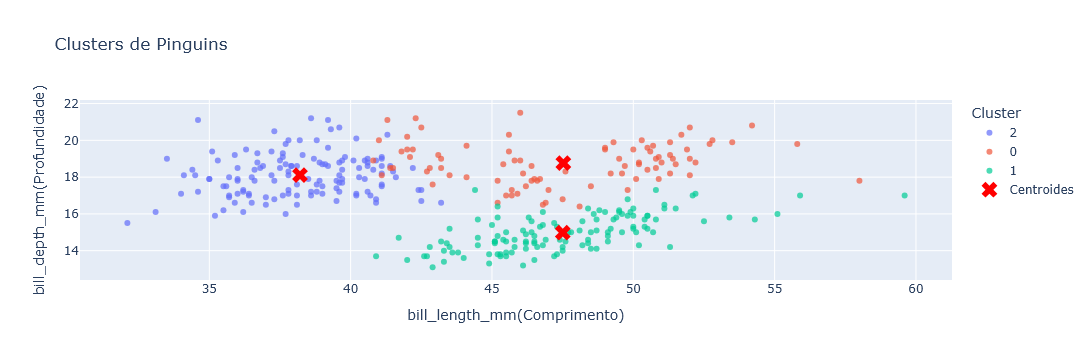

In [25]:
# Criando um df com os dados originais e  rótulos de cluster
df_clusters = pd.DataFrame({
    'bill_length_mm': penguins['bill_length_mm'],
    'bill_depth_mm': penguins['bill_depth_mm'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(df_clusters, x='bill_length_mm', y='bill_depth_mm', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters de Pinguins')

# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='bill_length_mm(Comprimento)', yaxis_title='bill_depth_mm(Profundidade)',
                  legend_title='Cluster')
fig.show()

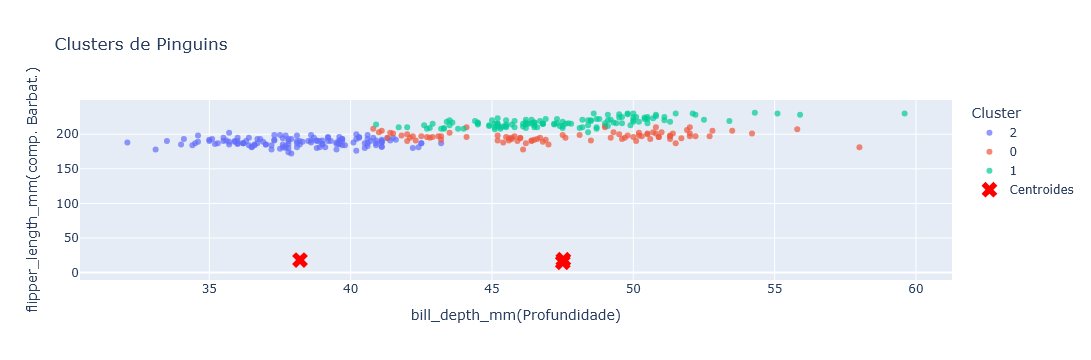

In [22]:
# Criando um df com os dados originais e  rótulos de cluster
df_clusters = pd.DataFrame({
    'bill_depth_mm': penguins['bill_length_mm'],
    'flipper_length_mm': penguins['flipper_length_mm'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(df_clusters, x='bill_depth_mm', y='flipper_length_mm', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters de Pinguins')

# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='bill_depth_mm(Profundidade)', yaxis_title='flipper_length_mm(comp. Barbat.)',
                  legend_title='Cluster')
fig.show()

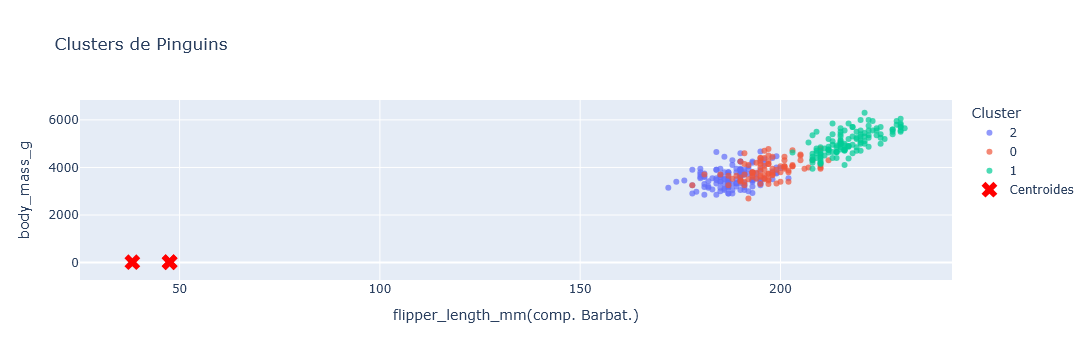

In [24]:
# Criando um df com os dados originais e  rótulos de cluster
df_clusters = pd.DataFrame({
    'flipper_length_mm': penguins['flipper_length_mm'],
    'body_mass_g': penguins['body_mass_g'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(df_clusters, x='flipper_length_mm', y='body_mass_g', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='Clusters de Pinguins')

# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='flipper_length_mm(comp. Barbat.)', yaxis_title='body_mass_g',
                  legend_title='Cluster')
fig.show()

# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo:

1. Indicação de musicas em streamings de música como youtube, amazon music e spotify. Uma vez identificando a qual grupo de musica os usuários pertencem fica mais facil indicar outras músicas do mesmo gênero ao usuário. Isso aumenta a fidelidade da pessoa, desencorajando ele de buscar outras plataformas para uso.
2. Indicação de filmes e séries na Netflix, Prime e Disney é um novo exemplo. Segue a mesma lógica do item 1. Verificando qual generô de filmes os usuários mais assistem, podemos indicar outros filmes e séries do mesmo grupo afim de fidelizar o usuário.
3. Atendimento ao cliente. Podemos usar o algoritmo para identificar grupos de reclamações semelhantes para criar soluções para cada problema detectado.